# HunyuanVideo-1.5：从首帧到视频

## 480P I2V Step-Distilled 官方推理与模块级拆解

本 Notebook 面向课堂讲解，包含两条主线：

1. **官方可运行推理**：加载官方 Diffusers checkpoint，输入一张首帧和文本，输出 MP4。
2. **模块级拆解**：分别观察文本编码器、SigLIP 图像编码器、3D Causal VAE、I2V 条件、5D 视频 latent、Video DiT、Flow Matching scheduler、MeanFlow 少步去噪和 VAE 解码。

学习目标：

- 理解视频 latent 为什么是 `[B, C, T, H, W]`。
- 理解首帧如何同时通过 VAE latent 和视觉语义 token 条件化视频。
- 理解 65 通道 DiT 输入的来源。
- 理解 Step-Distilled checkpoint 为什么可以把 50 步降到 8/12 步。
- 能区分 `num_frames`、`fps` 和 `num_inference_steps`。

> 本 Notebook 的实际出片部分调用官方 pipeline。后半部分的“手工拆解”用于教学观察，不建议在生产代码中复制维护。


## 0. 官方依据

本 Notebook 主要参考：

- [腾讯 HunyuanVideo-1.5 官方仓库](https://github.com/Tencent-Hunyuan/HunyuanVideo-1.5)
- [HunyuanVideo-1.5 Technical Report](https://arxiv.org/abs/2511.18870)
- [480P I2V Step-Distilled Diffusers 模型卡](https://huggingface.co/hunyuanvideo-community/HunyuanVideo-1.5-Diffusers-480p_i2v_step_distilled)
- [官方 Step Distillation 对比](https://github.com/Tencent-Hunyuan/HunyuanVideo-1.5/blob/main/assets/step_distillation_comparison.md)
- [Diffusers HunyuanVideo-1.5 文档](https://huggingface.co/docs/diffusers/main/api/pipelines/hunyuan_video15)
- [Diffusers I2V pipeline 源码](https://github.com/huggingface/diffusers/blob/main/src/diffusers/pipelines/hunyuan_video1_5/pipeline_hunyuan_video1_5_image2video.py)
- [Diffusers 3D Causal VAE 源码](https://github.com/huggingface/diffusers/blob/main/src/diffusers/models/autoencoders/autoencoder_kl_hunyuanvideo15.py)
- [Diffusers Video DiT 源码](https://github.com/huggingface/diffusers/blob/main/src/diffusers/models/transformers/transformer_hunyuan_video15.py)

已由公开配置确认的事实：

- 生成主干是约 **8.3B 参数**的 Video DiT。
- VAE latent channel 为 32；空间压缩 16 倍，时间压缩 4 倍。
- I2V DiT 输入为 `32 + 32 + 1 = 65` 通道。
- DiT 有 54 个双流 block、16 个 attention head，每个 head 128 维。
- Step-Distilled checkpoint 的 `use_meanflow=true`。
- 官方推荐 8 或 12 步；4 步更快但质量会下降。

边界说明：官方发布说明和 checkpoint 已公开推理行为，但**没有完整公开 Step Distillation 的 teacher、loss 权重和数据配方**。因此本 Notebook 会详细解释可从配置和推理源码验证的 MeanFlow 机制，不会伪造未公开训练细节。


## 1. 运行要求

推荐课堂环境：

- Linux + NVIDIA GPU。
- 官方说明开启 offload 后最低约 14GB 显存；RTX 4090 24GB 更稳妥。
- 建议至少预留约 50GB 磁盘缓存和较充足的系统内存。
- 第一次运行需要下载数十 GB 权重，务必在课前下载并完成一次预热。
- 121 帧、24 FPS 对应约 5 秒视频。

不建议在普通 CPU 或 Apple MPS 上进行课堂现场完整推理。


In [1]:
# 安装后如果 import 仍找不到 HunyuanVideo15ImageToVideoPipeline，重启 kernel 再运行。
# 课堂环境建议提前制作并冻结镜像，不要在上课时临时安装。
# 当前 AutoDL 环境已安装 diffusers 0.40.0 / transformers 5.15.1，跳过现场升级以免覆盖冻结依赖。
# %pip install -U "diffusers>=0.36.0" "transformers>=4.57.0" accelerate sentencepiece imageio-ffmpeg matplotlib

# 若镜像中的稳定版仍未包含该类，可改用 Diffusers 官方 main，然后重启 kernel：
# %pip install -U git+https://github.com/huggingface/diffusers.git
print("Skip live pip install; using preinstalled packages.")


Skip live pip install; using preinstalled packages.


In [2]:
import gc
import inspect
import os
import platform
import time
from pathlib import Path

# AutoDL：系统盘只有 30GB，且 huggingface.co 不可达，必须先设置镜像和数据盘缓存。
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
os.environ["HF_HOME"] = "/root/autodl-tmp/huggingface"
os.environ["HF_HUB_CACHE"] = "/root/autodl-tmp/huggingface/hub"
os.environ["HF_HUB_DISABLE_XET"] = "1"
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "0"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.nn.attention import SDPBackend, sdpa_kernel
from IPython.display import Video, display

from diffusers import HunyuanVideo15ImageToVideoPipeline
from diffusers.utils import export_to_video, load_image

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError("本 Notebook 的完整推理需要 NVIDIA CUDA GPU。")

print("GPU:", torch.cuda.get_device_name(0))
total_vram = torch.cuda.get_device_properties(0).total_memory / 1024**3
print(f"VRAM: {total_vram:.1f} GB")
print("BF16 supported:", torch.cuda.is_bf16_supported())

if total_vram < 14:
    print("警告：显存低于官方 offload 配置的推荐下限，可能 OOM。")


Python: 3.12.3
PyTorch: 2.8.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 4080 SUPER
VRAM: 31.5 GB
BF16 supported: True


## 2. 课堂参数

这里使用官方示例首帧。模型会根据输入图像比例和 `target_size=640` 自动选择与 VAE 对齐的 480P 尺寸，因此官方 `__call__` 不需要手动传入高宽。

`NUM_FRAMES=121`、`FPS=24` 时：

$$\text{duration} \approx \frac{121}{24}=5.04\text{s}$$

`NUM_STEPS` 控制生成模型调用次数；它和视频帧数、播放 FPS 是三个不同概念。


In [3]:
MODEL_ID = "/root/autodl-tmp/models/HunyuanVideo-1.5-Diffusers-480p_i2v_step_distilled"
IMAGE_URL = "/root/autodl-tmp/hunyuanvideo15_outputs/guitar-man.png"

PROMPT = (
    "A man with short gray hair plays a red electric guitar. "
    "His hands move naturally along the strings and fretboard. "
    "Subtle body movement, realistic cloth motion, a slow camera push-in, "
    "stable identity, continuous shot, cinematic natural lighting."
)

NEGATIVE_PROMPT = (
    "flicker, jump cut, sudden scene change, duplicated limbs, distorted hands, "
    "identity change, static frame, low quality"
)

SEED = 42
NUM_FRAMES = 121
NUM_STEPS = 12       # 官方推荐 8 或 12；4 步用于快速消融
FPS = 24

OUTPUT_DIR = Path("/root/autodl-tmp/hunyuanvideo15_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
OFFICIAL_OUTPUT = OUTPUT_DIR / "hunyuan15_i2v_step12.mp4"


## 3. 模型总览

整体推理链路：

```text
Prompt ──> Qwen2.5-VL text encoder ───────────────┐
       └─> ByT5 glyph encoder ───────────────────┤
                                                │
First frame ──> SigLIP visual tokens ───────────┤
      └───────> 3D Causal VAE latent + mask ────┤
                                                ▼
5D Gaussian noise ───────────────────────> Video DiT
                                                │
                                  Flow scheduler updates latent
                                                │
                                                ▼
                                  3D Causal VAE decoder
                                                │
                                                ▼
                                        121 frames -> MP4
```

首帧走两条路径：

- **VAE latent 路径**保留精确构图、颜色和局部像素信息，并只锚定第一个 latent 时间片。
- **SigLIP 路径**提供高层视觉语义 token，帮助 DiT 理解人物、物体和场景。

两条路径互补，不是简单重复。


## 4. 加载官方 Diffusers pipeline

课堂配置只选一种显存策略：这里使用 `enable_model_cpu_offload()`。不要再同时调用 `pipe.to("cuda")` 或 `device_map="cuda"`，否则可能破坏 offload 策略或直接 OOM。

VAE tiling 会把高分辨率编解码拆成 tile，降低峰值显存。


In [4]:
load_start = time.perf_counter()

pipe = HunyuanVideo15ImageToVideoPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
)

pipe.enable_model_cpu_offload()
pipe.vae.enable_tiling()
pipe.vae.enable_slicing()

# 官方 processor 会把 padding mask 扩成 [B,1,S,S]。121 帧时 S 很大，单这一步就要约 5GB，32GB 卡会 OOM。
# 改成可广播的 [B,1,1,S] key-padding mask，语义等价，显存从 O(S^2) 降到 O(S)。
import torch.nn.functional as F
from diffusers.models.attention_dispatch import dispatch_attention_fn
from diffusers.models.embeddings import apply_rotary_emb
from diffusers.models.transformers.transformer_hunyuan_video15 import HunyuanVideo15AttnProcessor2_0

def _lowmem_attn_call(self, attn, hidden_states, encoder_hidden_states=None, attention_mask=None, image_rotary_emb=None):
    query = attn.to_q(hidden_states)
    key = attn.to_k(hidden_states)
    value = attn.to_v(hidden_states)
    query = query.unflatten(2, (attn.heads, -1))
    key = key.unflatten(2, (attn.heads, -1))
    value = value.unflatten(2, (attn.heads, -1))
    query = attn.norm_q(query)
    key = attn.norm_k(key)
    if image_rotary_emb is not None:
        query = apply_rotary_emb(query, image_rotary_emb, sequence_dim=1)
        key = apply_rotary_emb(key, image_rotary_emb, sequence_dim=1)
    if encoder_hidden_states is not None:
        encoder_query = attn.add_q_proj(encoder_hidden_states)
        encoder_key = attn.add_k_proj(encoder_hidden_states)
        encoder_value = attn.add_v_proj(encoder_hidden_states)
        encoder_query = encoder_query.unflatten(2, (attn.heads, -1))
        encoder_key = encoder_key.unflatten(2, (attn.heads, -1))
        encoder_value = encoder_value.unflatten(2, (attn.heads, -1))
        if attn.norm_added_q is not None:
            encoder_query = attn.norm_added_q(encoder_query)
        if attn.norm_added_k is not None:
            encoder_key = attn.norm_added_k(encoder_key)
        query = torch.cat([query, encoder_query], dim=1)
        key = torch.cat([key, encoder_key], dim=1)
        value = torch.cat([value, encoder_value], dim=1)
    batch_size, seq_len, heads, dim = query.shape
    attention_mask = F.pad(attention_mask, (seq_len - attention_mask.shape[1], 0), value=True)
    attention_mask = attention_mask.bool().view(batch_size, 1, 1, seq_len)
    hidden_states = dispatch_attention_fn(
        query, key, value, attn_mask=attention_mask, dropout_p=0.0, is_causal=False,
        backend=self._attention_backend, parallel_config=self._parallel_config,
    )
    hidden_states = hidden_states.flatten(2, 3).to(query.dtype)
    if encoder_hidden_states is not None:
        hidden_states, encoder_hidden_states = (
            hidden_states[:, : -encoder_hidden_states.shape[1]],
            hidden_states[:, -encoder_hidden_states.shape[1] :],
        )
        if getattr(attn, "to_out", None) is not None:
            hidden_states = attn.to_out[0](hidden_states)
            hidden_states = attn.to_out[1](hidden_states)
        if getattr(attn, "to_add_out", None) is not None:
            encoder_hidden_states = attn.to_add_out(encoder_hidden_states)
    return hidden_states, encoder_hidden_states

HunyuanVideo15AttnProcessor2_0.__call__ = _lowmem_attn_call

print(f"Pipeline loaded in {(time.perf_counter() - load_start):.1f}s")
print("Pipeline class:", type(pipe).__name__)
print("Execution device:", pipe._execution_device)


/root/miniconda3/lib/python3.12/site-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Loading pipeline components...:   0%|          | 0/10 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/448 [00:00<?, ?it/s]

Guiders are currently an experimental feature under active development. The API is subject to breaking changes in future releases.


Loading weights:   0%|          | 0/111 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Pipeline loaded in 1.6s
Pipeline class: HunyuanVideo15ImageToVideoPipeline
Execution device: cuda:0


### 4.1 直接读取模型参数

官方所称的 8.3B 主要指生成主干 Video DiT。完整 Diffusers pipeline 还包含 Qwen2.5-VL、ByT5、SigLIP 和 VAE，所以端到端加载参数与下载体积更大。

下一个 cell 从真实对象统计参数，不使用讲义里写死的近似值。


In [5]:
def parameter_count(module):
    return sum(p.numel() for p in module.parameters())

modules = {
    "Video DiT": pipe.transformer,
    "3D Causal VAE": pipe.vae,
    "Qwen2.5-VL text": pipe.text_encoder,
    "ByT5 glyph text": pipe.text_encoder_2,
    "SigLIP image": pipe.image_encoder,
}

for name, module in modules.items():
    count = parameter_count(module)
    try:
        dtype = next(module.parameters()).dtype
    except StopIteration:
        dtype = "n/a"
    print(f"{name:20s} {count / 1e9:8.3f} B parameters, dtype={dtype}")

cfg = pipe.transformer.config
hidden_size = cfg.num_attention_heads * cfg.attention_head_dim
ffn_size = int(hidden_size * cfg.mlp_ratio)

print("\nVideo DiT config")
print("  task_type:", cfg.task_type)
print("  in_channels / out_channels:", cfg.in_channels, "/", cfg.out_channels)
print("  layers / refiner layers:", cfg.num_layers, "/", cfg.num_refiner_layers)
print("  heads x head_dim:", cfg.num_attention_heads, "x", cfg.attention_head_dim)
print("  hidden size:", hidden_size)
print("  FFN size:", ffn_size)
print("  RoPE axes:", cfg.rope_axes_dim)
print("  patch (T, H, W):", cfg.patch_size_t, cfg.patch_size, cfg.patch_size)
print("  use_meanflow:", cfg.use_meanflow)

print("\nVAE config")
print("  latent_channels:", pipe.vae.config.latent_channels)
print("  spatial compression:", pipe.vae.spatial_compression_ratio)
print("  temporal compression:", pipe.vae.temporal_compression_ratio)
print("  scaling_factor:", pipe.vae.config.scaling_factor)

print("\nScheduler:", type(pipe.scheduler).__name__)
print(pipe.scheduler.config)
print("\nGuider:", pipe.guider)


Video DiT               8.331 B parameters, dtype=torch.bfloat16
3D Causal VAE           1.261 B parameters, dtype=torch.bfloat16
Qwen2.5-VL text         7.071 B parameters, dtype=torch.bfloat16
ByT5 glyph text         0.219 B parameters, dtype=torch.bfloat16
SigLIP image            0.428 B parameters, dtype=torch.bfloat16

Video DiT config
  task_type: i2v
  in_channels / out_channels: 65 / 32
  layers / refiner layers: 54 / 2
  heads x head_dim: 16 x 128
  hidden size: 2048
  FFN size: 8192
  RoPE axes: [16, 56, 56]
  patch (T, H, W): 1 1 1
  use_meanflow: True

VAE config
  latent_channels: 32
  spatial compression: 16
  temporal compression: 4
  scaling_factor: 1.03682

Scheduler: FlowMatchEulerDiscreteScheduler
FrozenDict({'num_train_timesteps': 1000, 'shift': 7.0, 'use_dynamic_shifting': False, 'base_shift': 0.5, 'max_shift': 1.15, 'base_image_seq_len': 256, 'max_image_seq_len': 4096, 'invert_sigmas': False, 'shift_terminal': None, 'use_karras_sigmas': False, 'use_exponential_sig

## 5. 输入首帧

Pipeline 会先根据原图宽高比计算目标尺寸，再进行 crop resize。这个尺寸一定与 VAE 的 16 倍空间压缩对齐。


Original image size (W, H): (928, 512)
Model input size (W, H): (848, 480)


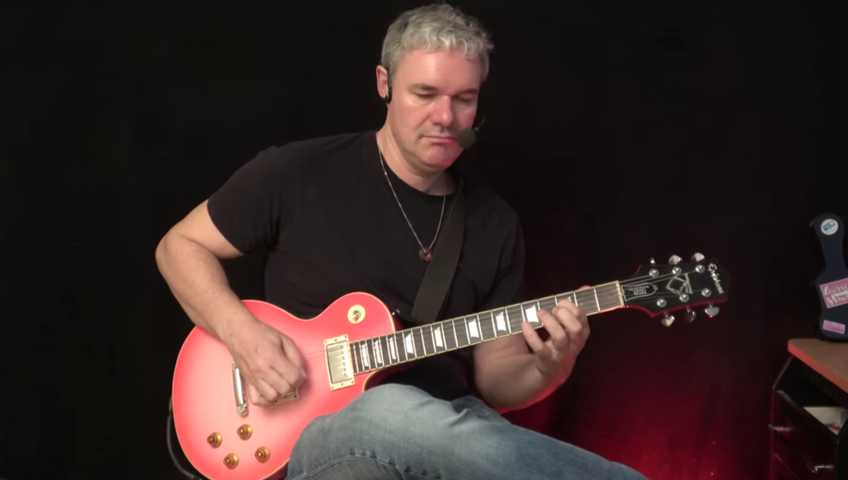

In [6]:
image = load_image(IMAGE_URL).convert("RGB")
print("Original image size (W, H):", image.size)

target_h, target_w = pipe.video_processor.calculate_default_height_width(
    height=image.size[1],
    width=image.size[0],
    target_size=pipe.target_size,
)
image_resized = pipe.video_processor.resize(
    image,
    height=target_h,
    width=target_w,
    resize_mode="crop",
)

print("Model input size (W, H):", image_resized.size)
display(image_resized)


## 6. 官方端到端推理：生成 MP4

下面是课堂真正用于出片的代码。它沿用官方模型卡流程，并增加了固定 seed、负面提示和计时。

Step-Distilled 权重推荐 8 或 12 步。官方报告 RTX 4090 使用该模型时端到端生成可以控制在约 75 秒量级，但实际时间会受 offload、CPU 内存、磁盘缓存和 attention backend 影响。


In [7]:
generator = torch.Generator(device="cuda").manual_seed(SEED)

if OFFICIAL_OUTPUT.exists() and OFFICIAL_OUTPUT.stat().st_size > 50_000:
    import imageio
    reader = imageio.get_reader(str(OFFICIAL_OUTPUT))
    frames = [frame for frame in reader]
    print("Reusing existing video:", OFFICIAL_OUTPUT.resolve())
    print("Frames:", len(frames))
    print(f"Duration at {FPS} fps: {len(frames) / FPS:.2f}s")
else:
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    start = time.perf_counter()

    # 4080 SUPER 32GB：禁止 MATH SDPA，避免 121 帧 attention 再申请约 5GB 导致 OOM。
    with sdpa_kernel([SDPBackend.FLASH_ATTENTION, SDPBackend.EFFICIENT_ATTENTION], set_priority=True):
        result = pipe(
            image=image,
            prompt=PROMPT,
            negative_prompt=NEGATIVE_PROMPT,
            generator=generator,
            num_frames=NUM_FRAMES,
            num_inference_steps=NUM_STEPS,
        )

    frames = result.frames[0]
    elapsed = time.perf_counter() - start
    peak_gb = torch.cuda.max_memory_allocated() / 1024**3
    export_to_video(frames, str(OFFICIAL_OUTPUT), fps=FPS)
    print("Saved:", OFFICIAL_OUTPUT.resolve())
    print("Frames:", len(frames))
    print(f"Duration at {FPS} fps: {len(frames) / FPS:.2f}s")
    print(f"Generation time: {elapsed:.1f}s")
    print(f"Peak allocated CUDA memory: {peak_gb:.2f}GB")


Reusing existing video: /root/autodl-tmp/hunyuanvideo15_outputs/hunyuan15_i2v_step12.mp4
Frames: 121
Duration at 24 fps: 5.04s


In [8]:
Video(str(OFFICIAL_OUTPUT), embed=True, width=800)


### 6.1 关键帧与相邻帧变化

相邻帧像素差只能叫“变化量”或“运动活跃度”，不能单独叫时间一致性：真实大运动和闪烁都会产生较大差值。


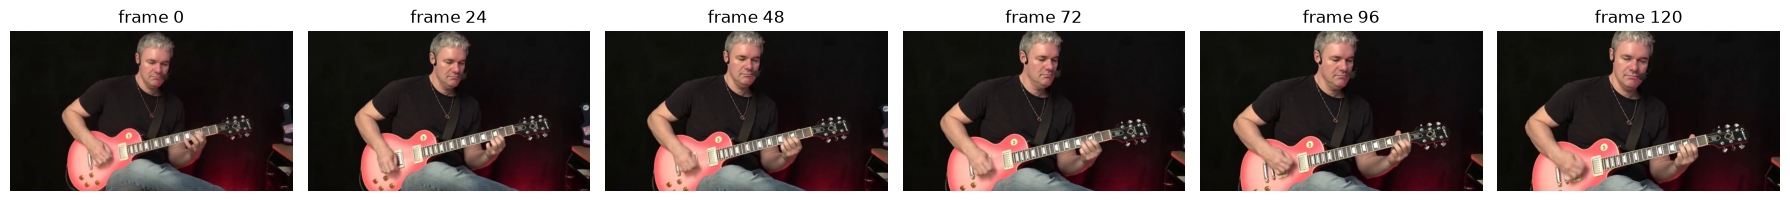

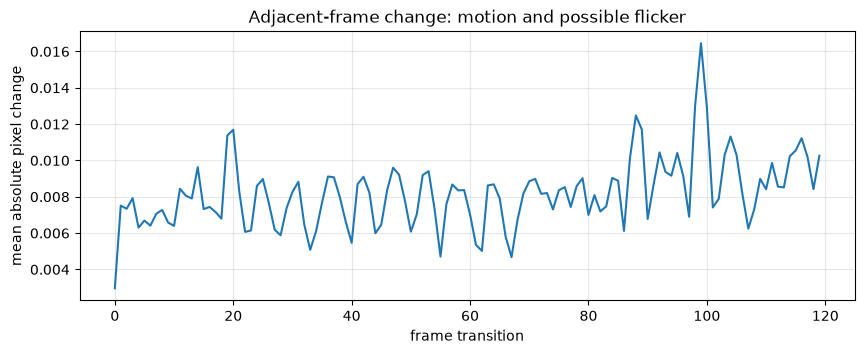

In [9]:
frame_array = np.asarray(frames, dtype=np.float32) / 255.0
key_indices = np.linspace(0, len(frames) - 1, 6, dtype=int)

fig, axes = plt.subplots(1, len(key_indices), figsize=(18, 4))
for ax, idx in zip(axes, key_indices):
    ax.imshow(frame_array[idx])
    ax.set_title(f"frame {idx}")
    ax.axis("off")
plt.tight_layout()
plt.show()

adjacent_change = np.abs(frame_array[1:] - frame_array[:-1]).mean(axis=(1, 2, 3))
plt.figure(figsize=(10, 3.5))
plt.plot(adjacent_change)
plt.xlabel("frame transition")
plt.ylabel("mean absolute pixel change")
plt.title("Adjacent-frame change: motion and possible flicker")
plt.grid(alpha=0.3)
plt.show()


# 7. 模块级拆解

后续 cell 会保留一些中间 tensor，因此显存紧张时不要与多组消融同时运行。完整官方推理已经在上一节完成；这里的目标是理解每个模块的输入输出。


## 7.1 文本条件：Qwen2.5-VL + ByT5

模型不是只有一个 CLIP 文本编码器：

- **Qwen2.5-VL text model**：把完整视频描述编码为 3584 维 token，负责主体、动作、环境、镜头等语义。
- **ByT5 glyph encoder**：只抽取 prompt 引号中的文字，输出 1472 维 token，用于改善画面中文字形。

官方 pipeline 会给 prompt 添加系统模板，并从 Qwen2.5-VL 的隐藏层中裁掉模板前缀。ByT5 最长 256 token；没有引号文字时返回零条件。


In [10]:
device = pipe._execution_device
dtype = pipe.transformer.dtype

# 加入引号文字，可以观察 ByT5 mask 变为非零。
teaching_prompt = PROMPT + ' A small illuminated sign reads "LIVE".'

with torch.inference_mode():
    (
        prompt_embeds,
        prompt_mask,
        glyph_embeds,
        glyph_mask,
    ) = pipe.encode_prompt(
        prompt=teaching_prompt,
        device=device,
        dtype=dtype,
        batch_size=1,
        num_videos_per_prompt=1,
    )

print("Qwen prompt embeddings:", tuple(prompt_embeds.shape))
print("Qwen valid tokens:", int(prompt_mask.sum()))
print("ByT5 glyph embeddings:", tuple(glyph_embeds.shape))
print("ByT5 valid tokens:", int(glyph_mask.sum()))
print("Expected feature dims:", cfg.text_embed_dim, "and", cfg.text_embed_2_dim)


Qwen prompt embeddings: (1, 1000, 3584)
Qwen valid tokens: 62
ByT5 glyph embeddings: (1, 256, 1472)
ByT5 valid tokens: 14
Expected feature dims: 3584 and 1472


## 7.2 SigLIP 图像语义编码器

SigLIP 将首帧转成视觉 token。它描述“图像中有什么”，而 VAE latent 更关注“像素和构图是什么样”。这些视觉 token 会进入 DiT 的条件分支。


In [11]:
with torch.inference_mode():
    image_embeds = pipe.encode_image(
        image=image_resized,
        batch_size=1,
        device=device,
        dtype=dtype,
    )

print("SigLIP image embeddings:", tuple(image_embeds.shape))
print("Configured image feature dim:", cfg.image_embed_dim)


SigLIP image embeddings: (1, 729, 1152)
Configured image feature dim: 1152


## 7.3 3D Causal VAE Encoder / Decoder

输入视频 tensor 排列为 `[B, C, T, H, W]`。单张首帧也要增加时间维，变成 `[1, 3, 1, H, W]`。

VAE 的作用：

- Encoder 输出高斯后验的均值和方差。
- I2V 条件使用 posterior 的 **mode**，而不是随机 sample，保证首帧条件稳定。
- 32 通道 latent 相对 RGB 像素显著降低时空尺寸。
- Decoder 将最终 latent 恢复为 RGB 帧。

“Causal”表示时间卷积不会读取未来帧来编码当前帧，从而保持时间方向。空间上仍然使用普通二维邻域。


Pixel tensor: (1, 3, 1, 480, 848)
First-frame latent: (1, 32, 1, 30, 53)
Reconstruction: (480, 848, 3)


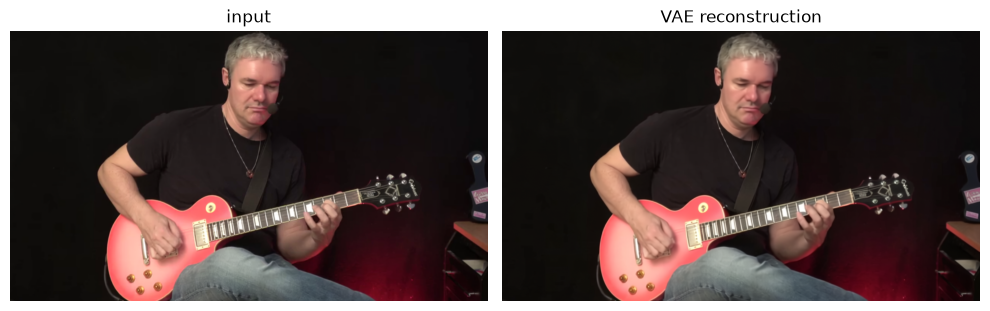

In [12]:
# PIL -> [B, 3, H, W] -> [B, 3, 1, H, W]
pixel_values = pipe.video_processor.preprocess(
    image_resized,
    height=target_h,
    width=target_w,
).to(device=device, dtype=pipe.vae.dtype)
pixel_values = pixel_values.unsqueeze(2)

with torch.inference_mode():
    posterior = pipe.vae.encode(pixel_values)
    first_frame_latent = posterior.latent_dist.mode()
    first_frame_latent = first_frame_latent * pipe.vae.config.scaling_factor

    # 重建时先除掉 scaling_factor。
    reconstruction = pipe.vae.decode(
        first_frame_latent / pipe.vae.config.scaling_factor,
        return_dict=False,
    )[0]
    reconstruction = pipe.video_processor.postprocess_video(
        reconstruction,
        output_type="np",
    )[0][0]

print("Pixel tensor:", tuple(pixel_values.shape))
print("First-frame latent:", tuple(first_frame_latent.shape))
print("Reconstruction:", reconstruction.shape)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(image_resized)
axes[0].set_title("input")
axes[1].imshow(reconstruction)
axes[1].set_title("VAE reconstruction")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


### 查看官方 CausalConv3d 实现

这里直接打印已安装 Diffusers 中官方类的源码。课堂上可以重点看 forward 前的时间 padding：左侧补历史帧，右侧不补未来帧。


In [13]:
from diffusers.models.autoencoders.autoencoder_kl_hunyuanvideo15 import HunyuanVideo15CausalConv3d

def show_source(obj, max_lines=100):
    lines = inspect.getsource(obj).splitlines()
    print("\n".join(lines[:max_lines]))
    if len(lines) > max_lines:
        print(f"... omitted {len(lines) - max_lines} lines")

show_source(HunyuanVideo15CausalConv3d.forward, max_lines=80)


    def forward(self, hidden_states: torch.Tensor) -> torch.Tensor:
        hidden_states = F.pad(hidden_states, self.time_causal_padding, mode=self.pad_mode)
        return self.conv(hidden_states)


## 7.4 初始化 5D 噪声 latent，并构造 I2V 条件

对 121 帧视频：

$$T_{latent}=\frac{121-1}{4}+1=31$$

$$H_{latent}=H/16,\quad W_{latent}=W/16$$

I2V 条件构造方式：

1. 初始化 32 通道高斯噪声。
2. 将首帧 VAE latent 放在另一个 32 通道 tensor 的第 0 个时间片，其余时间片为零。
3. 创建 1 通道 mask，第 0 个时间片为 1，其余为 0。
4. 拼接后得到 `32 + 32 + 1 = 65` 通道，送给 DiT。


In [14]:
# 使用新 generator，保证这个教学分支与前面的完整推理相互独立。
latent_generator = torch.Generator(device="cuda").manual_seed(SEED)

with torch.inference_mode():
    noise_latents = pipe.prepare_latents(
        batch_size=1,
        num_channels_latents=pipe.num_channels_latents,
        height=target_h,
        width=target_w,
        num_frames=NUM_FRAMES,
        dtype=dtype,
        device=device,
        generator=latent_generator,
    )

    cond_latents, cond_mask = pipe.prepare_cond_latents_and_mask(
        latents=noise_latents,
        image=image_resized,
        batch_size=1,
        height=target_h,
        width=target_w,
        dtype=dtype,
        device=device,
    )

    dit_input = torch.cat([noise_latents, cond_latents, cond_mask], dim=1)

print("Noise latent:", tuple(noise_latents.shape))
print("First-frame condition:", tuple(cond_latents.shape))
print("Condition mask:", tuple(cond_mask.shape))
print("DiT input:", tuple(dit_input.shape))
print("DiT configured in_channels:", cfg.in_channels)
print("Mask over latent time:", cond_mask[0, 0, :, 0, 0].float().cpu().tolist())


Noise latent: (1, 32, 31, 30, 53)
First-frame condition: (1, 32, 31, 30, 53)
Condition mask: (1, 1, 31, 30, 53)
DiT input: (1, 65, 31, 30, 53)
DiT configured in_channels: 65
Mask over latent time: [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


## 7.5 Video DiT：时空 token 与条件注意力

关键参数：

- 54 个双流 Transformer block。
- hidden size = `16 heads × 128 = 2048`。
- FFN 宽度约为 `2048 × 4 = 8192`。
- 3D RoPE 维度分配为 `[16, 56, 56]`，分别编码时间、高度和宽度位置。
- patch size 为 1，因此每个 latent 时空位置都成为一个视频 token。

DiT 内部不是逐帧独立处理：视频 token 带有时间与空间位置，并与文本、glyph 和图像条件共同计算 attention。这样模型才可能在时间轴上传递身份、运动和镜头信息。

技术报告还提出 SSTA（Selective and Sliding Tile Attention）用于长视频稀疏注意力加速，但本 Notebook 选择的 **480P I2V Step-Distilled checkpoint 使用标准/Flash joint attention，并不是 720P sparse checkpoint**。因此可以把 SSTA 作为架构族扩展讲解，不能声称本次现场推理正在执行 SSTA。

下面直接查看第一个真实 Transformer block 的类型和 forward 源码开头。


In [15]:
block_container = None
for name in ("transformer_blocks", "blocks"):
    candidate = getattr(pipe.transformer, name, None)
    if candidate is not None:
        block_container = candidate
        print("Block container:", name)
        break

if block_container is None:
    raise AttributeError("当前 Diffusers 版本中未找到 transformer block 容器。")

first_block = block_container[0]
print("First block class:", type(first_block).__name__)
show_source(type(first_block).forward, max_lines=100)


Block container: transformer_blocks
First block class: HunyuanVideo15TransformerBlock
    def forward(
        self,
        hidden_states: torch.Tensor,
        encoder_hidden_states: torch.Tensor,
        temb: torch.Tensor,
        attention_mask: torch.Tensor | None = None,
        freqs_cis: tuple[torch.Tensor, torch.Tensor] | None = None,
        *args,
        **kwargs,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        # 1. Input normalization
        norm_hidden_states, gate_msa, shift_mlp, scale_mlp, gate_mlp = self.norm1(hidden_states, emb=temb)
        norm_encoder_hidden_states, c_gate_msa, c_shift_mlp, c_scale_mlp, c_gate_mlp = self.norm1_context(
            encoder_hidden_states, emb=temb
        )

        # 2. Joint attention
        attn_output, context_attn_output = self.attn(
            hidden_states=norm_hidden_states,
            encoder_hidden_states=norm_encoder_hidden_states,
            attention_mask=attention_mask,
            image_rotary_emb=freqs_cis,


## 7.6 Scheduler 与 Step-Distilled 的 `t -> r`

该 pipeline 使用 Flow Matching scheduler。普通 flow model 只给网络当前时间 `t`；这个 checkpoint 的 `use_meanflow=true`，每一步还要传入下一目标时间 `r`。

12 步不是生成 12 帧，而是在 flow 轨迹上进行 12 次较大的 latent 更新。每一步 DiT 预测从当前状态跨到下一个时刻所需的平均流/速度，scheduler 再更新 latent。


In [16]:
# 官方 pipeline 默认构造从 1 到 0 的 sigma 序列，再交给 scheduler。
sigmas = np.linspace(1.0, 0.0, NUM_STEPS + 1)[:-1]
pipe.scheduler.set_timesteps(sigmas=sigmas, device=device)
timesteps = pipe.scheduler.timesteps

print("Scheduler:", type(pipe.scheduler).__name__)
print("Number of timesteps:", len(timesteps))
print("Timesteps:", timesteps.detach().float().cpu().tolist())

for i in range(min(4, len(timesteps))):
    t = timesteps[i]
    r = timesteps[i + 1] if i + 1 < len(timesteps) else torch.tensor(0.0, device=device)
    print(f"step {i}: t={float(t):.4f} -> r={float(r):.4f}")


Scheduler: FlowMatchEulerDiscreteScheduler
Number of timesteps: 12
Timesteps: [1000.0, 987.1795043945312, 972.22216796875, 954.54541015625, 933.3333740234375, 907.4073486328125, 875.0, 833.3333129882812, 777.77783203125, 700.0, 583.3333740234375, 388.888916015625]
step 0: t=1000.0000 -> r=987.1795
step 1: t=987.1795 -> r=972.2222
step 2: t=972.2222 -> r=954.5454
step 3: t=954.5454 -> r=933.3334


## 7.7 单次 DiT 前向 + Scheduler 更新

这个 cell 对应官方去噪循环中的核心一步：

```text
65ch model input
    + Qwen text tokens
    + ByT5 glyph tokens
    + SigLIP image tokens
    + current t and target r
    -> Video DiT predicts flow
    -> scheduler.step updates 32ch noise latent
```

当前发布的 guider 配置为 guidance scale 1。为突出核心结构，下面只跑 conditional branch；生产出片仍以前面的官方 pipeline 为准。


In [17]:
RUN_ONE_DIT_STEP = True

if RUN_ONE_DIT_STEP:
    # 前面 teaching_prompt 含 "LIVE"。如果希望与正式视频完全一致，可重新 encode PROMPT。
    t = timesteps[0]
    r = timesteps[1] if len(timesteps) > 1 else torch.tensor(0.0, device=device)

    timestep = t.expand(noise_latents.shape[0]).to(noise_latents.dtype)
    timestep_r = r.expand(noise_latents.shape[0]).to(noise_latents.dtype)

    with torch.inference_mode():
        with sdpa_kernel([SDPBackend.FLASH_ATTENTION, SDPBackend.EFFICIENT_ATTENTION], set_priority=True):
            predicted_flow = pipe.transformer(
                hidden_states=dit_input,
                image_embeds=image_embeds,
                timestep=timestep,
                timestep_r=timestep_r,
                encoder_hidden_states=prompt_embeds,
                encoder_attention_mask=prompt_mask,
                encoder_hidden_states_2=glyph_embeds,
                encoder_attention_mask_2=glyph_mask,
                return_dict=False,
            )[0]

        latent_after_one_step = pipe.scheduler.step(
            predicted_flow,
            t,
            noise_latents,
            return_dict=False,
        )[0]

    print("Predicted flow:", tuple(predicted_flow.shape))
    print("Latent before:", tuple(noise_latents.shape), float(noise_latents.float().std()))
    print("Latent after :", tuple(latent_after_one_step.shape), float(latent_after_one_step.float().std()))
else:
    print("Skipped. Set RUN_ONE_DIT_STEP=True to execute one 8.3B DiT forward pass.")


Predicted flow: (1, 32, 31, 30, 53)
Latent before: (1, 32, 31, 30, 53) 0.9993149638175964
Latent after : (1, 32, 31, 30, 53) 0.9868543744087219


## 7.8 完整手工去噪循环：教学版

下面把核心模块串起来。它等价展示当前 guidance scale 1 checkpoint 的 conditional path：初始化噪声、准备 I2V 条件、循环传入 `t` 和 `r`、scheduler 更新、VAE 解码。

默认不再次运行，因为前面的官方 pipeline 已经完成一次完整生成。设置 `RUN_MANUAL_LOOP=True` 会再生成一段视频。

注意：如果以后换成 guidance scale 大于 1、PAG 或其他 guider，必须使用 pipeline 的 guider 机制组合 conditional/unconditional prediction，不能照抄这个单分支教学循环。


In [18]:
RUN_MANUAL_LOOP = False

def manual_meanflow_i2v(num_steps=8, seed=SEED):
    # 1) 文本与图像语义条件
    with torch.inference_mode():
        p, p_mask, p2, p2_mask = pipe.encode_prompt(
            prompt=PROMPT,
            device=device,
            dtype=dtype,
            batch_size=1,
            num_videos_per_prompt=1,
        )
        img_tokens = pipe.encode_image(image_resized, 1, device, dtype)

    # 2) 5D 高斯噪声
    g = torch.Generator(device="cuda").manual_seed(seed)
    z = pipe.prepare_latents(
        batch_size=1,
        num_channels_latents=pipe.num_channels_latents,
        height=target_h,
        width=target_w,
        num_frames=NUM_FRAMES,
        dtype=dtype,
        device=device,
        generator=g,
    )

    # 3) 首帧 VAE latent 与 mask
    z_cond, z_mask = pipe.prepare_cond_latents_and_mask(
        latents=z,
        image=image_resized,
        batch_size=1,
        height=target_h,
        width=target_w,
        dtype=dtype,
        device=device,
    )

    # 4) MeanFlow 时间区间
    local_sigmas = np.linspace(1.0, 0.0, num_steps + 1)[:-1]
    pipe.scheduler.set_timesteps(sigmas=local_sigmas, device=device)
    local_timesteps = pipe.scheduler.timesteps

    # 5) Video DiT 去噪
    with torch.inference_mode():
        for i, t in enumerate(local_timesteps):
            r = (
                local_timesteps[i + 1]
                if i + 1 < len(local_timesteps)
                else torch.tensor(0.0, device=device)
            )
            model_input = torch.cat([z, z_cond, z_mask], dim=1)
            t_batch = t.expand(z.shape[0]).to(z.dtype)
            r_batch = r.expand(z.shape[0]).to(z.dtype)

            flow = pipe.transformer(
                hidden_states=model_input,
                image_embeds=img_tokens,
                timestep=t_batch,
                timestep_r=r_batch,
                encoder_hidden_states=p,
                encoder_attention_mask=p_mask,
                encoder_hidden_states_2=p2,
                encoder_attention_mask_2=p2_mask,
                return_dict=False,
            )[0]
            z = pipe.scheduler.step(flow, t, z, return_dict=False)[0]
            print(f"step {i + 1:02d}/{num_steps}: latent std={z.float().std().item():.4f}")

        # 6) 3D Causal VAE 解码
        z = z.to(pipe.vae.dtype) / pipe.vae.config.scaling_factor
        decoded = pipe.vae.decode(z, return_dict=False)[0]
        video = pipe.video_processor.postprocess_video(decoded, output_type="np")[0]

    return video

if RUN_MANUAL_LOOP:
    manual_frames = manual_meanflow_i2v(num_steps=8)
    manual_path = OUTPUT_DIR / "manual_meanflow_8step.mp4"
    export_to_video(manual_frames, str(manual_path), fps=FPS)
    print("Saved:", manual_path.resolve())
    display(Video(str(manual_path), embed=True, width=800))
else:
    print("Manual loop skipped. Set RUN_MANUAL_LOOP=True to generate a second video.")


Manual loop skipped. Set RUN_MANUAL_LOOP=True to generate a second video.


# 8. Step-Distilled 到底做了什么？

## 8.1 普通 Flow Matching

设数据 latent 为 $x_0$，噪声为 $\epsilon$，一种常见线性路径是：

$$x_t=(1-t)x_0+t\epsilon$$

当 $t=1$ 时接近噪声，当 $t=0$ 时回到数据。普通 flow model 学习当前点的瞬时速度：

$$v_\theta(x_t,t)\approx \frac{dx_t}{dt}$$

如果一次跨得太远，局部速度近似误差会放大，所以传统模型需要较多小步更新。

## 8.2 MeanFlow 式区间预测

这个 Step-Distilled checkpoint 的配置是 `use_meanflow=true`。网络同时接收当前时刻 $t$ 和目标时刻 $r$，学习区间上的平均流：

$$u_\theta(x_t,t,r)\approx \frac{x_r-x_t}{r-t}$$

更新可理解为：

$$x_r\approx x_t+(r-t)u_\theta(x_t,t,r)$$

因为网络直接针对较大的时间区间建模，所以一次前向可以跨过更长的去噪轨迹。8/12 次 DiT 调用便可能替代原模型约 50 次调用。

## 8.3 “蒸馏”的含义

可验证的部分：

- 原始 I2V 模型约 50 步；官方 Step-Distilled 模型推荐 8 或 12 步。
- 4 步也能运行，但官方说明质量略降。
- 网络没有缩成小模型，DiT 仍然约 8.3B 参数。
- checkpoint 配置启用 MeanFlow；推理源码每一步都传 `timestep=t` 与 `timestep_r=r`。
- 官方报告 RTX 4090 端到端时间最多降低约 75%。

未公开的部分：

- 完整 teacher/student 构造。
- 蒸馏 loss 的精确权重。
- 训练数据混合比例和所有 timestep 采样细节。

因此不能简单声称它一定使用了 LCM、DMD 或某个特定 teacher loss。更准确的课堂表述是：**这是保留原 DiT 容量、通过 MeanFlow 式区间目标适配少步推理的 Step-Distilled checkpoint。**

还要和 CFG Distillation 区分：官方仓库另行列出了 `cfg-distilled` checkpoint。当前 step-distilled Diffusers 权重的 guider scale 为 1，但官方没有完整公开两种蒸馏训练信号如何组合，不能仅凭文件名推断全部训练配方。


## 8.4 为什么 4 步会退化？

当步数从 12 降到 4，每次要跨越的时间区间变得更大：

- 区间平均流更难预测。
- 小的方向误差会在大步更新中被放大。
- 高频纹理、手部和快速运动更容易失真。
- 主体身份、背景结构和运动轨迹可能更不稳定。

少步生成不是“免费加速”，而是在模型容量、蒸馏训练和误差积累之间做新的平衡。


# 9. 课堂消融

建议不同小组各运行一组，避免每个人重复等待：

1. **步数消融**：同图、同 prompt、同 seed，比 4 / 8 / 12 步。
2. **动作提示消融**：固定镜头，只改变人物动作。
3. **镜头提示消融**：固定人物动作，只改变 locked camera / push-in / orbit。

比较时至少记录：推理时间、峰值显存、主体身份、手部、背景闪烁、动作连续性和 prompt 遵循。


In [19]:
RUN_ABLATIONS = False

def run_official(prompt, steps, seed, filename):
    g = torch.Generator(device="cuda").manual_seed(seed)
    torch.cuda.reset_peak_memory_stats()
    start = time.perf_counter()

    out = pipe(
        image=image,
        prompt=prompt,
        negative_prompt=NEGATIVE_PROMPT,
        generator=g,
        num_frames=NUM_FRAMES,
        num_inference_steps=steps,
    ).frames[0]

    elapsed = time.perf_counter() - start
    peak = torch.cuda.max_memory_allocated() / 1024**3
    path = OUTPUT_DIR / filename
    export_to_video(out, str(path), fps=FPS)
    return {"steps": steps, "seconds": elapsed, "peak_vram_gb": peak, "path": str(path)}

if RUN_ABLATIONS:
    records = []
    for steps in (4, 8, 12):
        records.append(
            run_official(PROMPT, steps, SEED, f"ablation_steps_{steps}.mp4")
        )
    for record in records:
        print(record)
else:
    print("Ablations skipped. Set RUN_ABLATIONS=True to run 4/8/12-step comparison.")


Ablations skipped. Set RUN_ABLATIONS=True to run 4/8/12-step comparison.


# 10. 常见问题与讲课提醒

**为什么最终会生成视频而不是一张图片？**  
DiT 去噪的是带时间维的 5D latent，VAE decoder 一次解码出整段帧序列，最后 `export_to_video` 将帧编码为 MP4。

**121 帧和 24 FPS 有什么区别？**  
121 帧决定模型生成多少时间内容；24 FPS 只决定这些帧的播放速度。修改 FPS 不会重新生成运动。

**为什么不是每帧分别做图像扩散？**  
分别生成会缺少跨帧共享的时空 token，极易发生身份漂移、背景跳变和动作不连续。

**Step-Distilled 是小模型吗？**  
不是。它主要减少 DiT 调用次数，主干参数量没有因此变成 4 步或 12 步的小网络。

**相邻帧差越小越好吗？**  
不是。完全静止的视频差值很小，快速但合理的运动差值会很大。需要结合人工观察、光流 warp error、感知特征和视频质量指标。

**为什么首次运行特别慢？**  
首次需要下载和加载数十 GB 权重，CPU offload 还会在 CPU 与 GPU 间搬运模型。课堂必须课前缓存和预热。

**为什么不建议手工循环作为最终代码？**  
官方 pipeline 还处理 guider、negative prompt、offload hooks、dtype、尺寸对齐和未来版本兼容。手工循环适合教学阅读，官方 pipeline 才是可靠推理入口。


# 11. 课后思考

1. 首帧已经通过 VAE latent 输入，为什么还需要 SigLIP token？
2. 如果将 I2V mask 从第 0 个 latent 时间片扩展到前 3 个，会变成什么条件任务？
3. 时间压缩比从 4 改成 8 会如何影响运动细节和 DiT token 数？
4. 为什么步数消融必须固定图像、prompt 和随机种子？
5. 4 步生成中的失败究竟来自 VAE、DiT、scheduler，还是区间预测误差？如何设计实验区分？
6. 如果逐帧图像质量很好但视频观看明显闪烁，应当如何设计评价指标？


# 附录：腾讯官方仓库原生推理入口

前面的 Diffusers pipeline 是官方支持的 Python 推理集成，最适合课堂 Notebook。腾讯仓库自身还提供 `generate.py` 原生入口，流程如下：

```bash
git clone https://github.com/Tencent-Hunyuan/HunyuanVideo-1.5.git
cd HunyuanVideo-1.5
pip install -r requirements.txt
```

下载官方 checkpoint 后，可执行：

```bash
torchrun --nproc_per_node=1 generate.py \
  --prompt 'A man plays a red electric guitar, continuous natural motion.' \
  --image_path ./input.png \
  --resolution 480p \
  --aspect_ratio 16:9 \
  --video_length 121 \
  --num_inference_steps 12 \
  --seed 42 \
  --rewrite false \
  --enable_step_distill true \
  --offloading true \
  --sr false \
  --output_path ./outputs/hunyuan15_native.mp4 \
  --model_path ./ckpts
```

这里关闭 prompt rewrite 和 super-resolution，是为了让课堂变量更少，并聚焦 480P 生成主干。官方仓库还支持 CFG-distilled、cache、SageAttention、super-resolution 和多卡推理，但不建议第一次上课同时开启。

原生仓库和 Diffusers 的模块对应关系：

| 原生/概念模块 | Diffusers 对象 |
|---|---|
| Qwen2.5-VL prompt encoder | `pipe.text_encoder` |
| Glyph ByT5 | `pipe.text_encoder_2` |
| SigLIP vision encoder | `pipe.image_encoder` |
| 3D Causal VAE | `pipe.vae` |
| Video DiT | `pipe.transformer` |
| Flow Matching sampler | `pipe.scheduler` |
| CFG/无 CFG 组合 | `pipe.guider` |

官方仓库入口适合工程部署；Diffusers 入口更适合在 Notebook 中逐个观察组件。


In [20]:
# 可选：课程结束后释放显存和 Python 引用。
# 如果还要继续做消融，不要先运行这一格。
CLEAN_UP = False

if CLEAN_UP:
    for name in [
        "result", "frames", "frame_array", "prompt_embeds", "glyph_embeds",
        "image_embeds", "noise_latents", "cond_latents", "cond_mask", "dit_input",
        "predicted_flow", "latent_after_one_step", "pixel_values", "first_frame_latent",
    ]:
        globals().pop(name, None)
    gc.collect()
    torch.cuda.empty_cache()
    print("Temporary tensors released.")
else:
    print("Cleanup skipped.")


Cleanup skipped.
